# Análisis exploratorio de los datos estructurados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#### Carga de datos

In [3]:
df_agri = pd.read_csv('datos/produccion_agricola.csv')
df_gana = pd.read_csv('datos/produccion_ganadera.csv')
df_precios = pd.read_csv('datos/precios_mercado.csv')
df_img = pd.read_csv('datos/imagenes_metadata.csv')

In [4]:
df_agri.head()

,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779
3,Argentina,ARG,América del Sur,Té,2011,188518,3.07,577886,236,8527,0.003623
4,Argentina,ARG,América del Sur,Algodón,2011,1638327,1.18,1929756,276,6925,0.007735


In [5]:
df_gana.head()

,pais,anio,tipo_ganado,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne
0,Argentina,2011,bovino,18160590,1857394,2355425160,1121740,0.062,0.1023
1,Argentina,2011,porcino,13481224,1528896,0,1984357,0.147,0.1134
2,Argentina,2011,avicola,979196737,1290153,0,10160819,0.010,0.0013
3,Argentina,2011,ovino,13789178,477282,329191349,5061273,0.367,0.0346
4,Argentina,2011,caprino,2045715,345732,454558689,284966,0.139,0.1690


In [6]:
df_precios.head()

,fecha,pais,producto,precio_usd_ton,volumen_operado_ton,tendencia_30_dias,mercado_principal,precio_min_mes,precio_max_mes
0,2021-01-01,Argentina,Carne_bovina,4299.14,127922,subiendo,UE,3844.74,4517.42
1,2021-01-01,Argentina,Arroz,330.04,73231,subiendo,Sudeste Asiático,310.10,359.86
2,2021-01-01,Argentina,Maíz,210.36,11666,bajando,Japón,200.56,238.83
3,2021-01-01,Brasil,Maíz,212.91,195579,subiendo,Oriente Medio,200.25,243.04
4,2021-01-01,Brasil,Leche,356.41,136137,subiendo,UE,348.39,390.03


In [7]:
df_img.head()

,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja
3,SAT_DEU_202003_003,Alemania,Región Principal,2020-03-12,0.601,0.446,0.655,0.744,urbano,0.644,0.209,60,Sentinel-2,"RGB, NIR, SWIR",media
4,SAT_FRA_202003_004,Francia,Región Principal,2020-03-22,0.639,0.518,0.753,0.792,mixto,0.441,0.249,10,Sentinel-2,"RGB, NIR, SWIR",baja


### Análisis agricola y satelite

#### 1. Fertilizantes vs Rendimiento

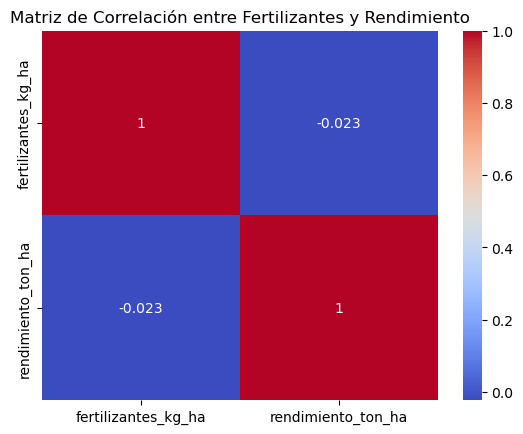

In [16]:
#Matriz de correlación para kg de fertilizante y rendimiento
correlation_matrix = df_agri[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Fertilizantes y Rendimiento')
plt.show()

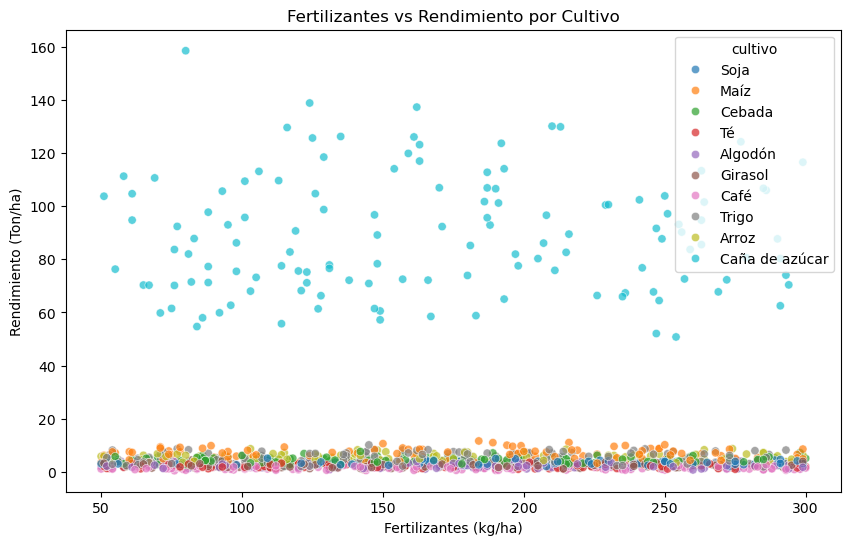

In [15]:
plt.figure(figsize=(10, 6)) 
sns.scatterplot(data=df_agri, x='fertilizantes_kg_ha', y='rendimiento_ton_ha', hue='cultivo', alpha=0.7)
plt.title('Fertilizantes vs Rendimiento por Cultivo')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (Ton/ha)')
plt.show()

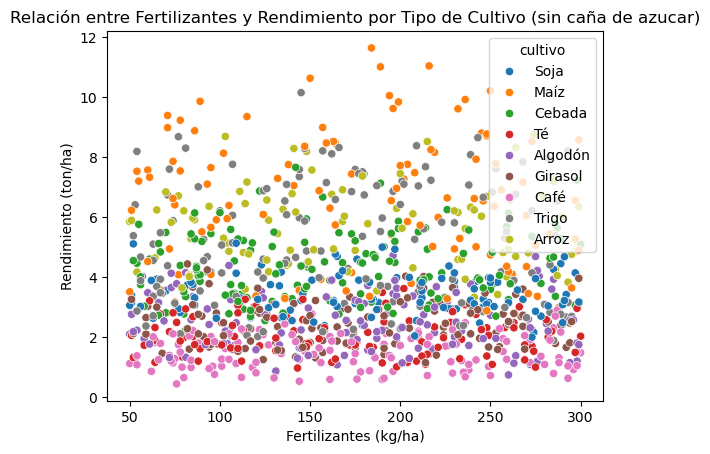

In [17]:
#Grafico de dispersión para kg de fertilizante y rendimiento quitando el cultivo de caña de azucar
df_sin_cana = df_agri[df_agri['cultivo'] != 'Caña de azúcar']
sns.scatterplot(x='fertilizantes_kg_ha', y='rendimiento_ton_ha', hue='cultivo', data=df_sin_cana)
plt.title('Relación entre Fertilizantes y Rendimiento por Tipo de Cultivo (sin caña de azucar)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.show()

#### 2. Superficie vs producción

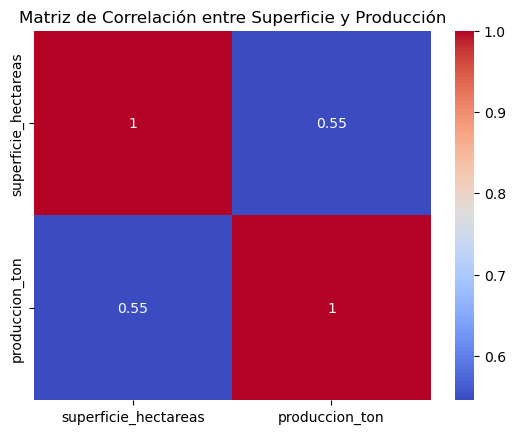

In [18]:
#Matriz de correlación para superficie y produccion
correlation_matrix = df_agri[['superficie_hectareas', 'produccion_ton']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Superficie y Producción')
plt.show()

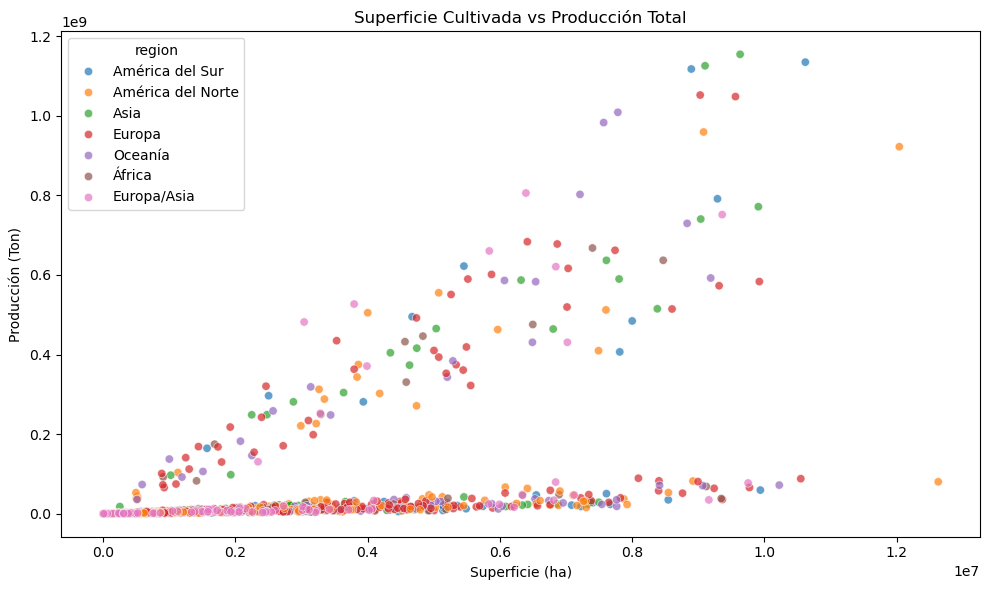

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_agri, x='superficie_hectareas', y='produccion_ton', hue='region', alpha=0.7)
plt.title('Superficie Cultivada vs Producción Total')
plt.xlabel('Superficie (ha)')
plt.ylabel('Producción (Ton)')
plt.tight_layout()
plt.show()

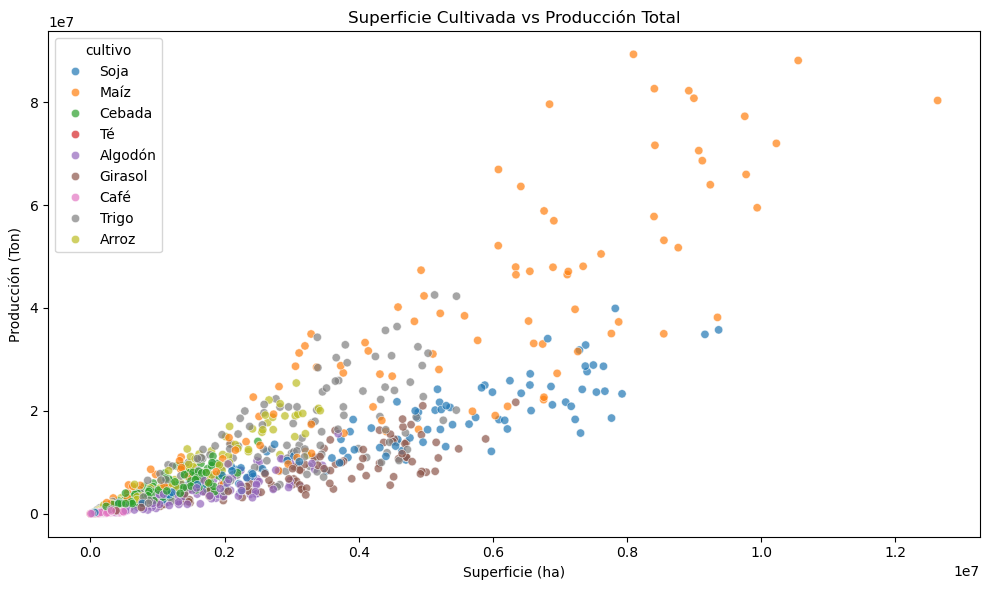

In [30]:
df_sin_cana = df_agri[df_agri['cultivo'] != 'Caña de azúcar']
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sin_cana, x='superficie_hectareas', y='produccion_ton', hue='cultivo', alpha=0.7)
plt.title('Superficie Cultivada vs Producción Total')
plt.xlabel('Superficie (ha)')
plt.ylabel('Producción (Ton)')
plt.tight_layout()
plt.show()

#### 3. Relación agua vs rendimiento

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_4376\1515975919.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


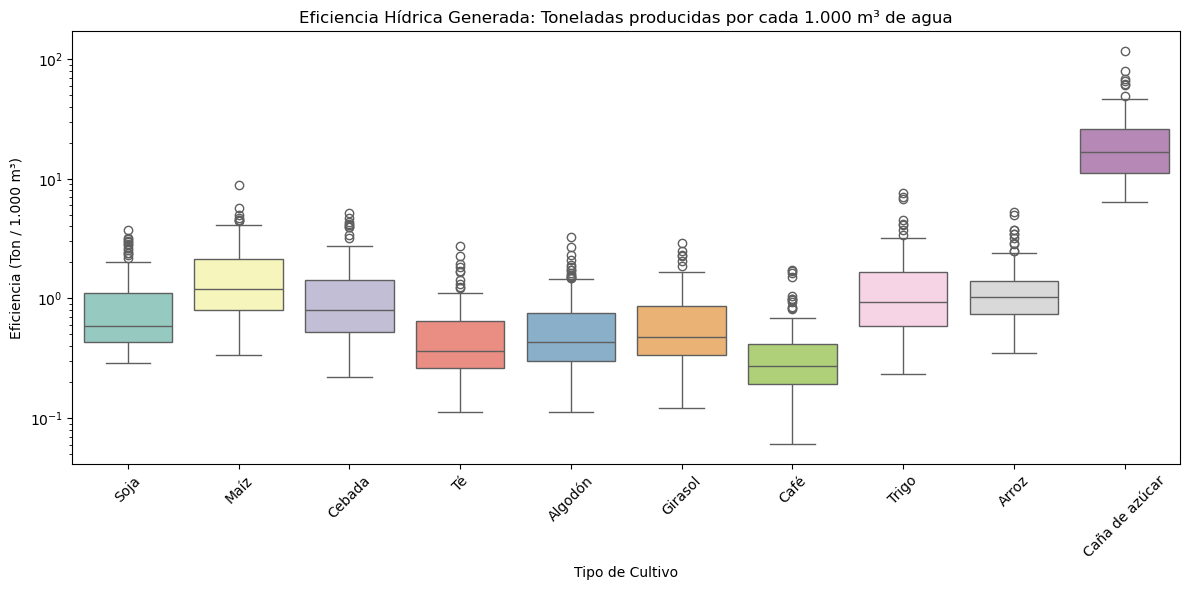

In [34]:
# Calculamos: ¿Cuántas toneladas produce con 1000 m3 de agua?
df_agri['eficiencia_hidrica'] = df_agri['rendimiento_ton_ha'] / (df_agri['agua_riego_m3_ha'] / 1000)

plt.figure(figsize=(12, 6))
# Usamos un boxplot para ver la distribución completa y la mediana por cultivo
sns.boxplot(
    data=df_agri, 
    x='cultivo', 
    y='eficiencia_hidrica', 
    palette='Set3'
)
plt.title('Eficiencia Hídrica Generada: Toneladas producidas por cada 1.000 m³ de agua')
plt.ylabel('Eficiencia (Ton / 1.000 m³)')
plt.xlabel('Tipo de Cultivo')
plt.xticks(rotation=45)
# Escala logarítmica si hay cultivos con eficiencias extremadamente altas/bajas
plt.yscale('log') 
plt.tight_layout()
plt.show()

#### 4. Relaciones satelitales

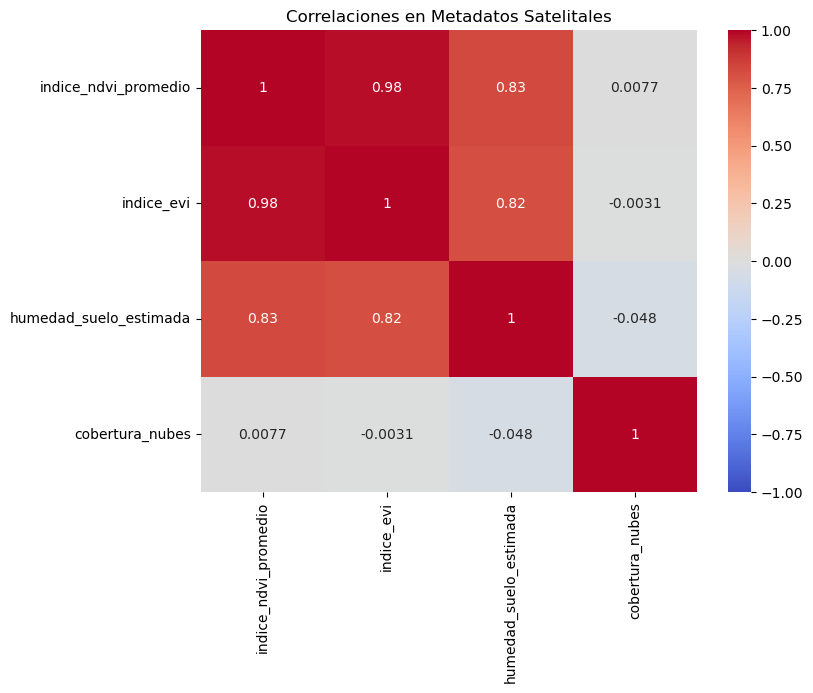

In [35]:
# Matriz Satelital
plt.figure(figsize=(8, 6))
cols_img = ['indice_ndvi_promedio', 'indice_evi', 'humedad_suelo_estimada', 'cobertura_nubes']
sns.heatmap(df_img[cols_img].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlaciones en Metadatos Satelitales')
plt.show()

### Análisis temporales 

#### 1. Tendencia de producción global por cultivo y pais

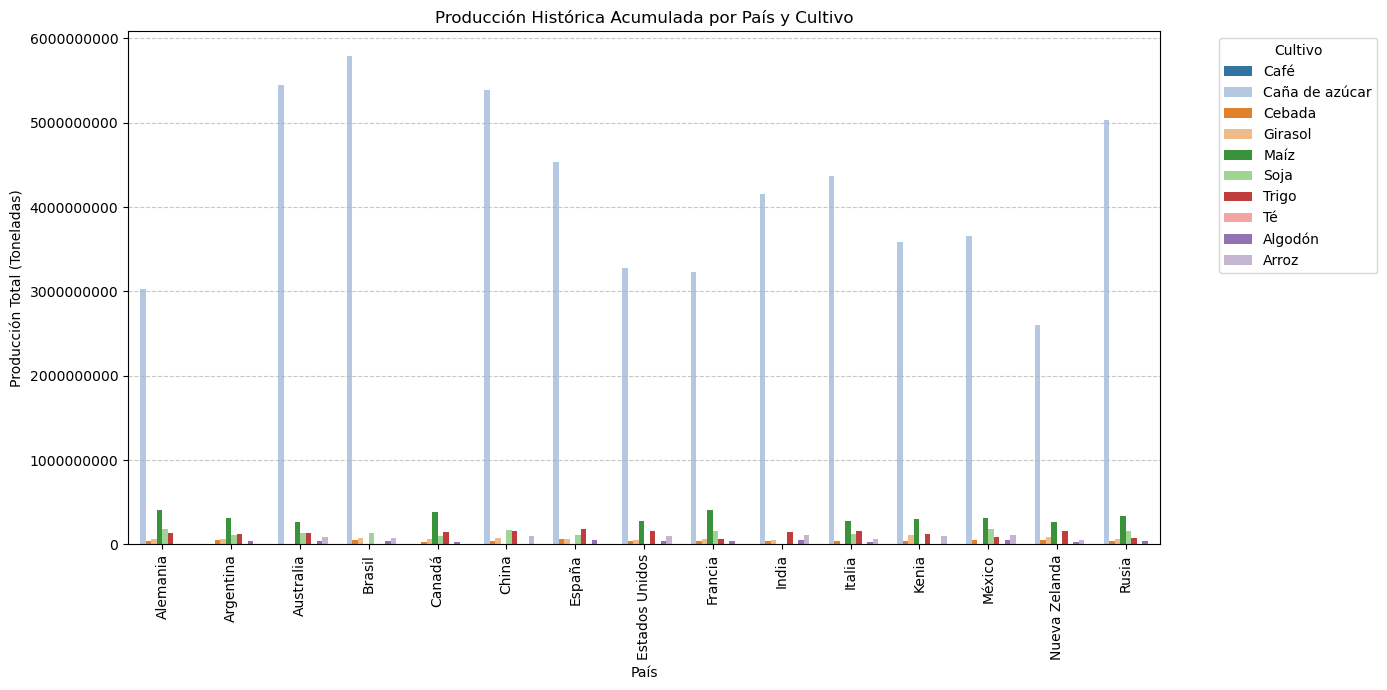

In [42]:
# Agrupar la producción sumando toneladas por País y Cultivo (sin Año)
prod_pais_cultivo = df_agri.groupby(['pais', 'cultivo'])['produccion_ton'].sum().reset_index()

# Identificar producción total
paises = df_agri.groupby('pais')['produccion_ton'].sum().index

# Filtrar el dataset agrupado solo para estos países
df_top = prod_pais_cultivo[prod_pais_cultivo['pais'].isin(paises)]

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
# Hacer que el valor de x sea vertical
plt.xticks(rotation=90)
sns.barplot(data=df_top, x='pais', y='produccion_ton', hue='cultivo', palette='tab20') 


plt.title('Producción Histórica Acumulada por País y Cultivo')
plt.xlabel('País')
plt.ylabel('Producción Total (Toneladas)')
plt.ticklabel_format(style='plain', axis='y') # Evitar notación científica
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

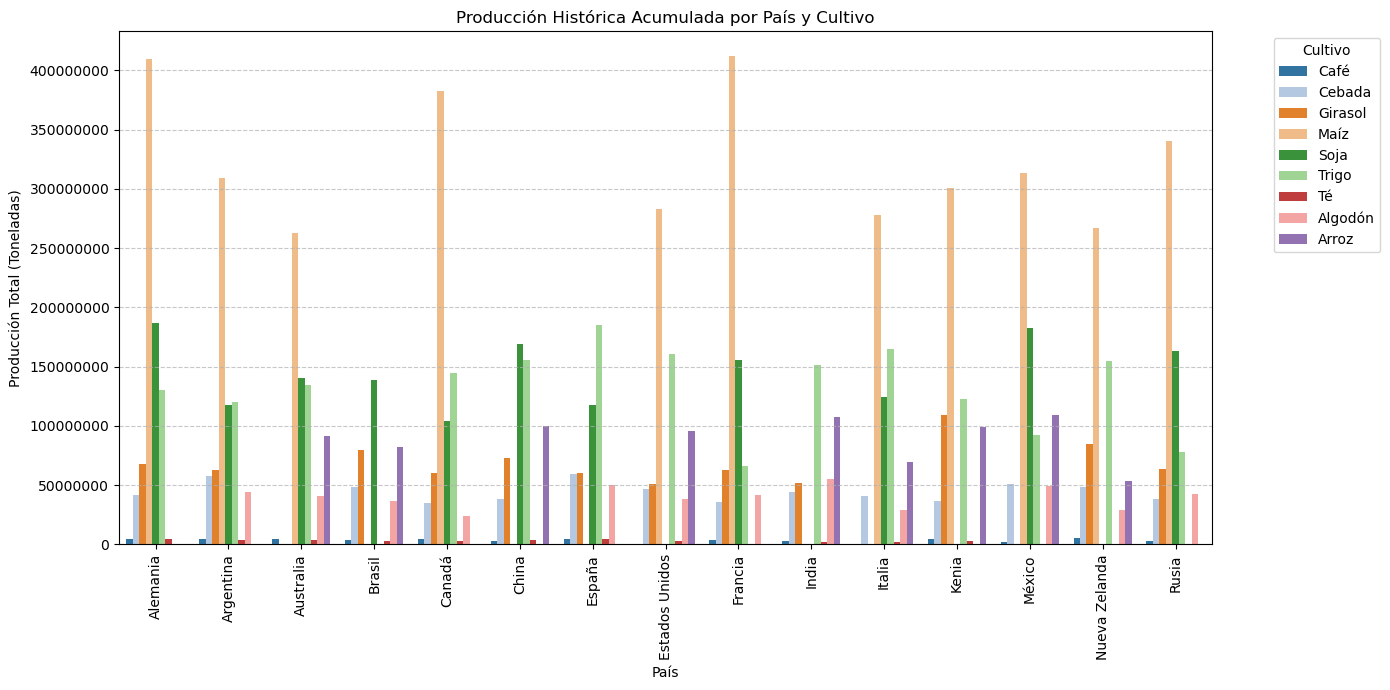

In [43]:
# Agrupar la producción sumando toneladas por País y Cultivo (sin Año)
prod_pais_cultivo = df_agri.groupby(['pais', 'cultivo'])['produccion_ton'].sum().reset_index()

prod_pais_cultivo_sin_cana = prod_pais_cultivo[prod_pais_cultivo['cultivo'] != 'Caña de azúcar']
# Identificar producción total
paises = df_agri.groupby('pais')['produccion_ton'].sum().index

# Filtrar el dataset agrupado solo para estos países
df_top = prod_pais_cultivo_sin_cana[prod_pais_cultivo_sin_cana['pais'].isin(paises)]

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
# Hacer que el valor de x sea vertical
plt.xticks(rotation=90)
sns.barplot(data=df_top, x='pais', y='produccion_ton', hue='cultivo', palette='tab20') 


plt.title('Producción Histórica Acumulada por País y Cultivo')
plt.xlabel('País')
plt.ylabel('Producción Total (Toneladas)')
plt.ticklabel_format(style='plain', axis='y') # Evitar notación científica
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

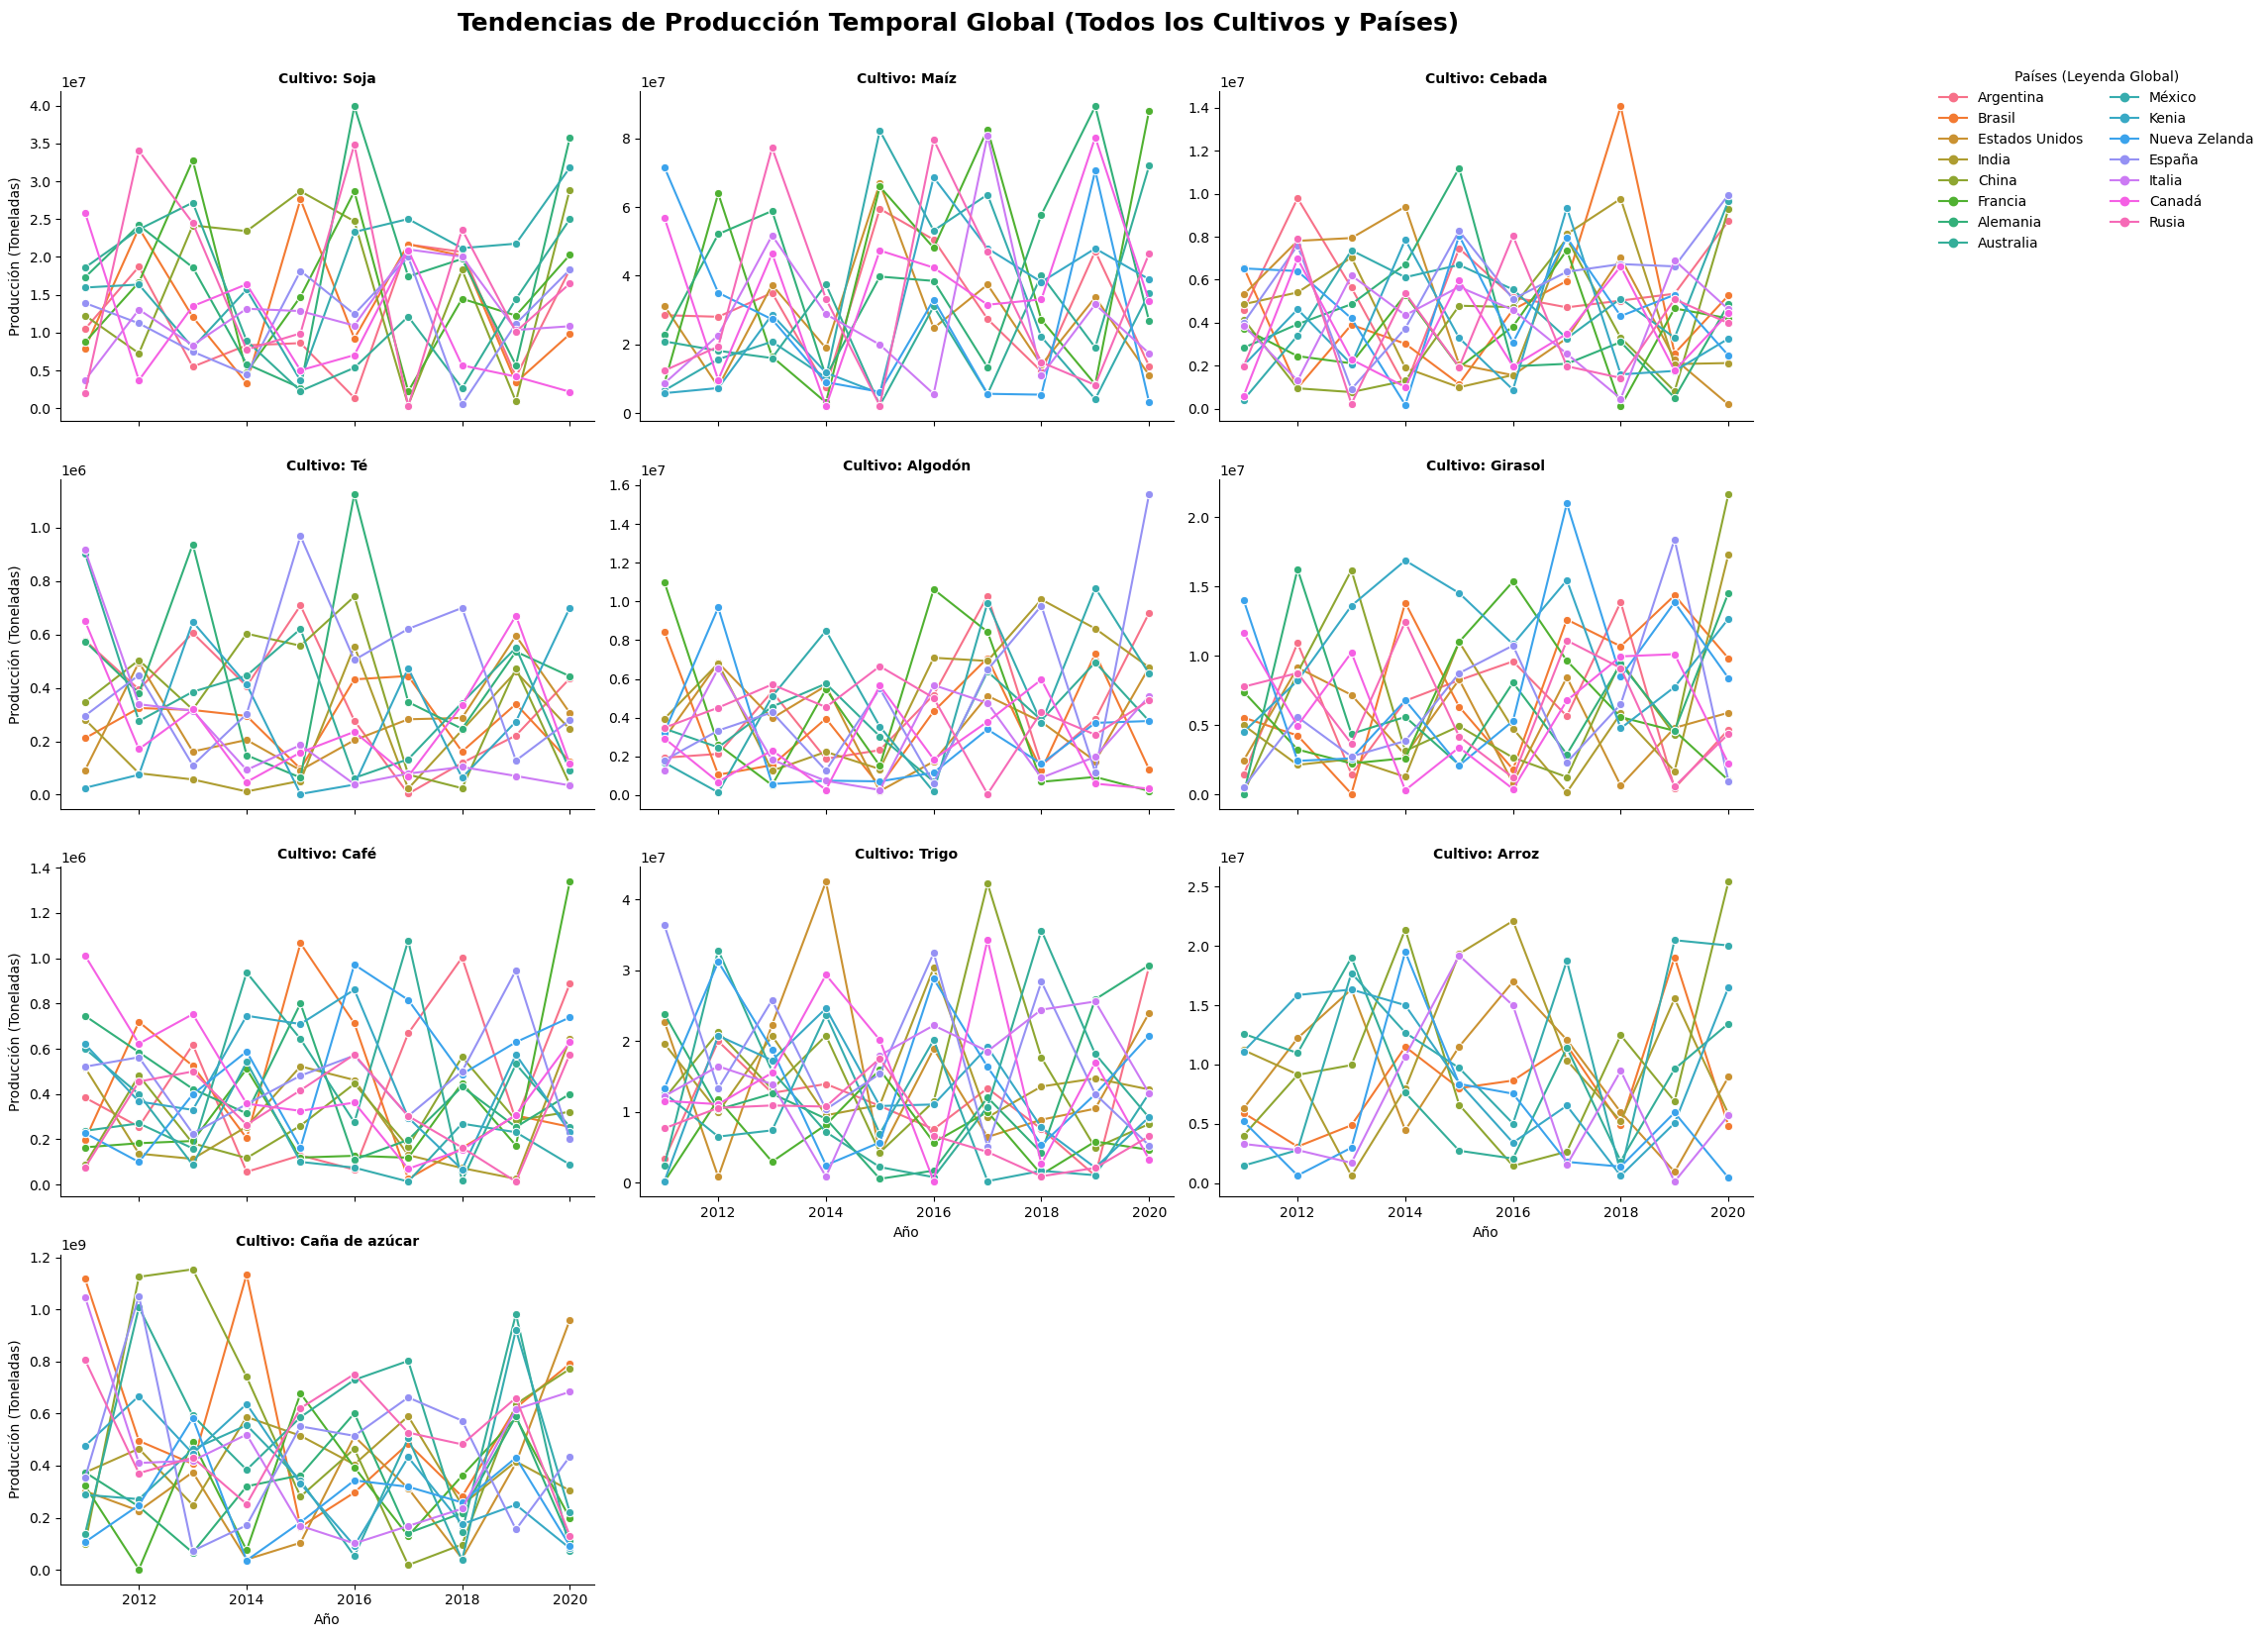

In [46]:
# ==========================================
# GENERACIÓN DE CUADRÍCULA DINÁMICA (FACET GRID)
# ==========================================
# Utilizamos relplot para crear múltiples subgráficas automáticamente
# basándose en la columna 'cultivo'
g = sns.relplot(
    data=df_agri,
    x='anio',
    y='produccion_ton',
    hue='pais',             # Una línea de color por cada país
    col='cultivo',          # Crea una gráfica nueva por cada cultivo
    col_wrap=3,             # Ponemos 3 gráficas por fila para que no sea infinito hacia la derecha
    kind='line',
    marker='o',
    height=4,               # Altura de cada subgráfica
    aspect=1.5,             # Anchura relativa de cada subgráfica
    facet_kws={'sharey': False}, # MUY IMPORTANTE: Cada gráfica tendrá su propia escala Y
    palette='husl'          # Paleta con muchos colores distintos
)

# ==========================================
# FORMATO Y ESTÉTICA
# ==========================================
# Título general
g.fig.suptitle('Tendencias de Producción Temporal Global (Todos los Cultivos y Países)', 
               y=1.03, fontsize=18, fontweight='bold')

# Nombres de los ejes
g.set_axis_labels('Año', 'Producción (Toneladas)')

# Título de cada cajita
g.set_titles('Cultivo: {col_name}', fontweight='bold')

# Como hay decenas de países, la leyenda por defecto tapará las gráficas. 
# La sacamos fuera de la cuadrícula y la ponemos en 2 columnas para que sea legible.
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), ncol=2, title='Países (Leyenda Global)')

plt.show()

### Geoestacional

c:\Users\Ccp0897\anaconda3\envs\piaentorno\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


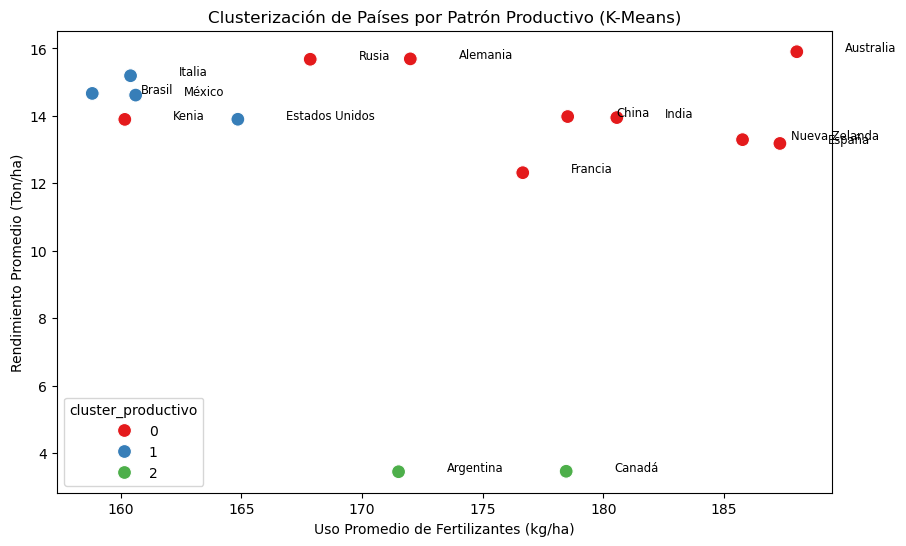

In [47]:
# ==========================================
# 4. ANÁLISIS GEOESPACIAL Y CLUSTERIZACIÓN (K-Means)
# ==========================================
# Agrupamos por país para ver el patrón promedio general
df_pais = df_agri.groupby('pais').agg({
    'rendimiento_ton_ha': 'mean',
    'fertilizantes_kg_ha': 'mean',
    'agua_riego_m3_ha': 'mean'
}).reset_index()

# Preparamos datos para clustering (escalado)
X_cluster = StandardScaler().fit_transform(df_pais[['rendimiento_ton_ha', 'fertilizantes_kg_ha', 'agua_riego_m3_ha']])

# Aplicamos K-Means (buscamos 3 clusters como pide el análisis de perfiles)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pais['cluster_productivo'] = kmeans.fit_predict(X_cluster)

# Visualizamos los clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pais, x='fertilizantes_kg_ha', y='rendimiento_ton_ha', 
                hue='cluster_productivo', palette='Set1', s=100)
for i in range(df_pais.shape[0]):
    plt.text(df_pais['fertilizantes_kg_ha'][i]+2, df_pais['rendimiento_ton_ha'][i], 
             df_pais['pais'][i], size='small')
plt.title('Clusterización de Países por Patrón Productivo (K-Means)')
plt.xlabel('Uso Promedio de Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento Promedio (Ton/ha)')
plt.show()